In [28]:
import pandas as pd

df = pd.read_csv("histories.csv")

# convert unix timestamp → datetime
df["datetime"] = pd.to_datetime(df["time"], unit="s")

# choose resolution (VERY important)
df["date"] = df["datetime"].dt.floor("D")   # daily
# or:
# df["hour"] = df["datetime"].dt.floor("H")

<Axes: title={'center': 'Infections over time'}, xlabel='date'>

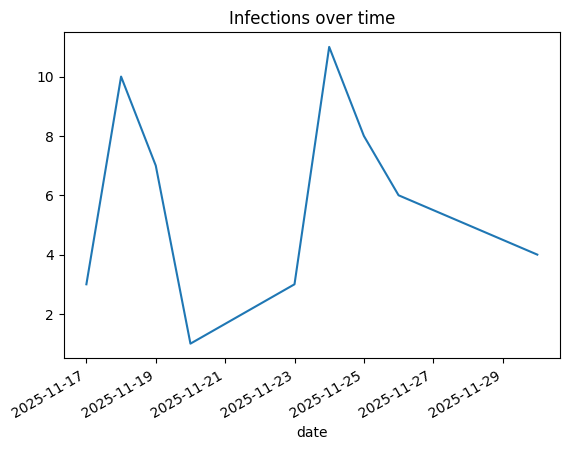

In [29]:
inf = df[df["type"] == "infection"]

inf_ts = inf.groupby("date").size()

inf_ts.plot(title="Infections over time")

<Axes: xlabel='date'>

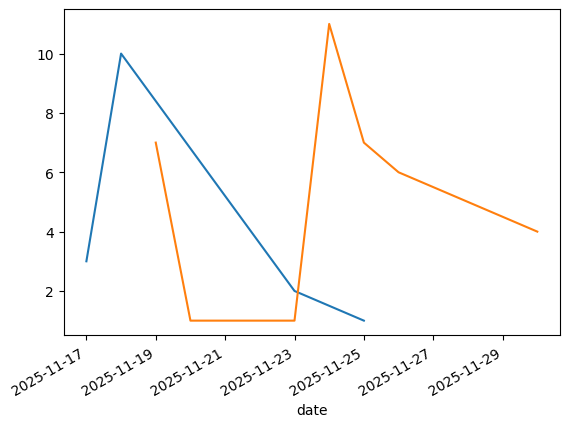

In [30]:
index_cases = inf[inf["inf"] == "CASE0[0]"]
peer_cases  = inf[inf["inf"].str.contains("PEER", na=False)]

index_cases.groupby("date").size().plot(label="Index")
peer_cases.groupby("date").size().plot(label="Peer")

<Axes: title={'center': 'Deaths over time'}, xlabel='date'>

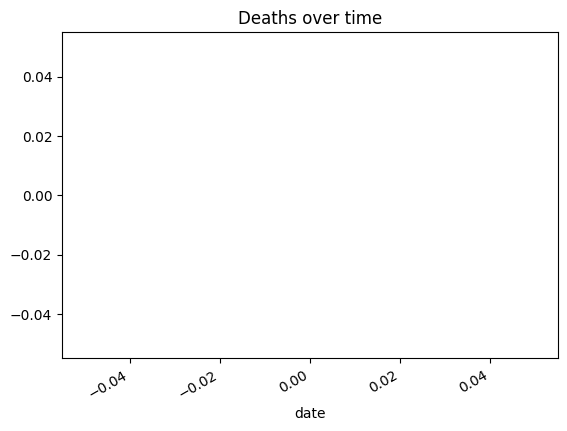

In [31]:
deaths = df[(df["type"] == "outcome") & (df["out"] == "dead")]

death_ts = deaths.groupby("date").size()

death_ts.plot(title="Deaths over time")

<Axes: title={'center': 'Recoveries'}, xlabel='date'>

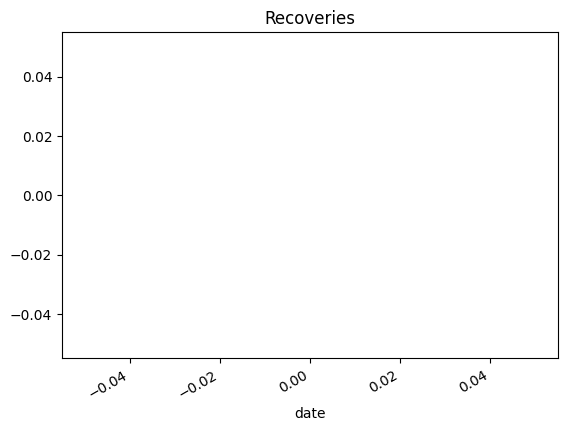

In [32]:
rec = df[(df["type"] == "outcome") & (df["out"] == "recovered")]

rec.groupby("date").size().plot(title="Recoveries")

<Axes: title={'center': 'Contacts per day'}, xlabel='date'>

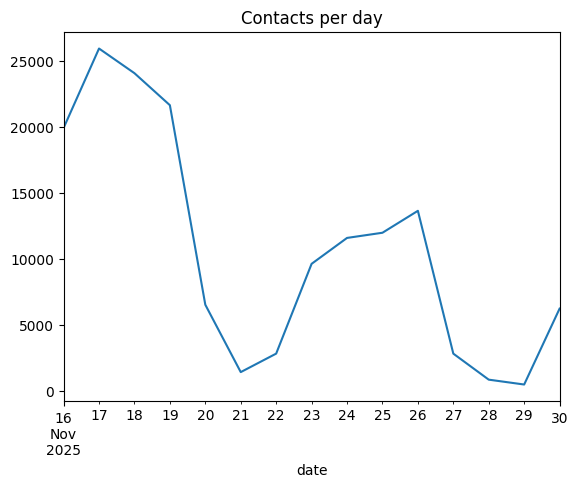

In [33]:
contacts = df[df["type"] == "contact"]

contacts_ts = contacts.groupby("date").size()

contacts_ts.plot(title="Contacts per day")

<Axes: title={'center': 'Total contact time'}, xlabel='date'>

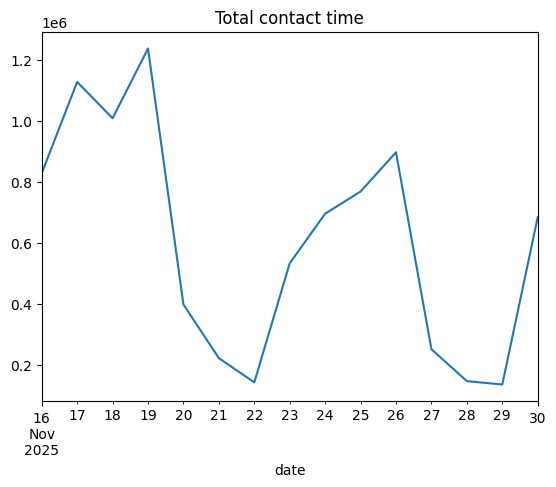

In [34]:
contacts["contact_seconds"] = contacts["contact_length"] / 1000

contacts.groupby("date")["contact_seconds"].sum().plot(title="Total contact time")

<Axes: title={'center': 'Active infections'}, xlabel='date'>

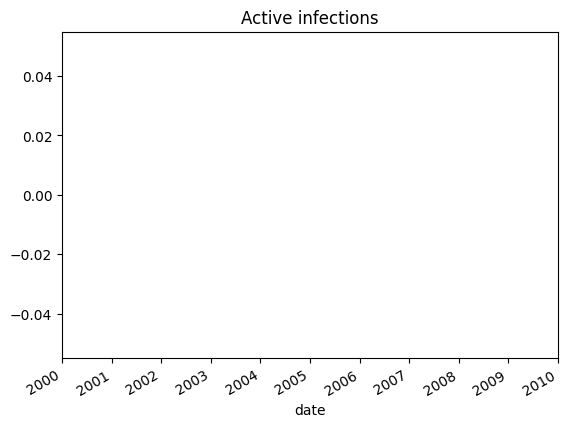

In [45]:
inf_events = df[df["type"] == "infection"]
rec_events = df[(df["type"] == "outcome") & (df["out"] == "RECOVERED")]
death_events = df[(df["type"] == "outcome") & (df["out"] == "DEAD")]
esc_events = df[(df["type"] == "outcome") & (df["out"] == "ESCAPED")]

inf_ts = inf_events.groupby("date").size()
rec_ts = rec_events.groupby("date").size()
death_ts = death_events.groupby("date").size()
esc_ts = esc_events.groupby("date").size()

active = inf_ts.cumsum() - rec_ts.cumsum() - death_ts.cumsum()
active.plot(title="Active infections")

In [64]:
scores = df[df["type"] == "score"]

scores

scores['out'] = scores['out'].astype(int)

score_ts = scores.groupby("date").size()




<Axes: title={'center': 'Behaviour over time'}, xlabel='date'>

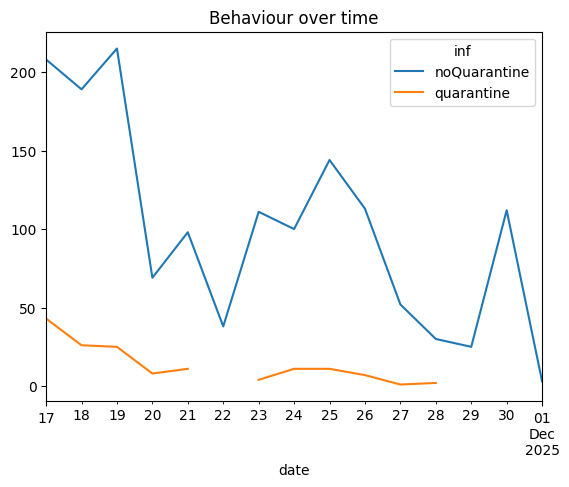

In [47]:
scores[scores["inf"].isin(["quarantine", "noQuarantine"])] \
    .groupby(["date", "inf"]).size() \
    .unstack().plot(title="Behaviour over time")

In [48]:
peer_inf = df[df["inf"].str.contains("PEER", na=False)]

peer_inf["source"] = peer_inf["inf"].str.extract(r"PEER\[(\d+):")[0]

# now you have edges:
# source → user_id

In [74]:
# --- TRUE ACTIVE CASES ---

df_sorted = df.sort_values("time").copy()
df_sorted["datetime"] = pd.to_datetime(df_sorted["time"], unit="s")
df_sorted["date"] = df_sorted["datetime"].dt.floor("D")

# define events
is_inf = df_sorted["type"] == "infection"
is_rec = (df_sorted["type"] == "outcome") & (df_sorted["out"] == "recovered")
is_dead = (df_sorted["type"] == "outcome") & (df_sorted["out"] == "dead")

# state change
df_sorted["delta"] = 0
df_sorted.loc[is_inf, "delta"] = 1
df_sorted.loc[is_rec | is_dead, "delta"] = -1

# cumulative infection state per user
df_sorted["state"] = df_sorted.groupby("user_id")["delta"].cumsum()

# count active users per day
active_true = (
    df_sorted[df_sorted["state"] > 0]
    .groupby("date")["user_id"]
    .nunique()
)

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>], dtype=object)

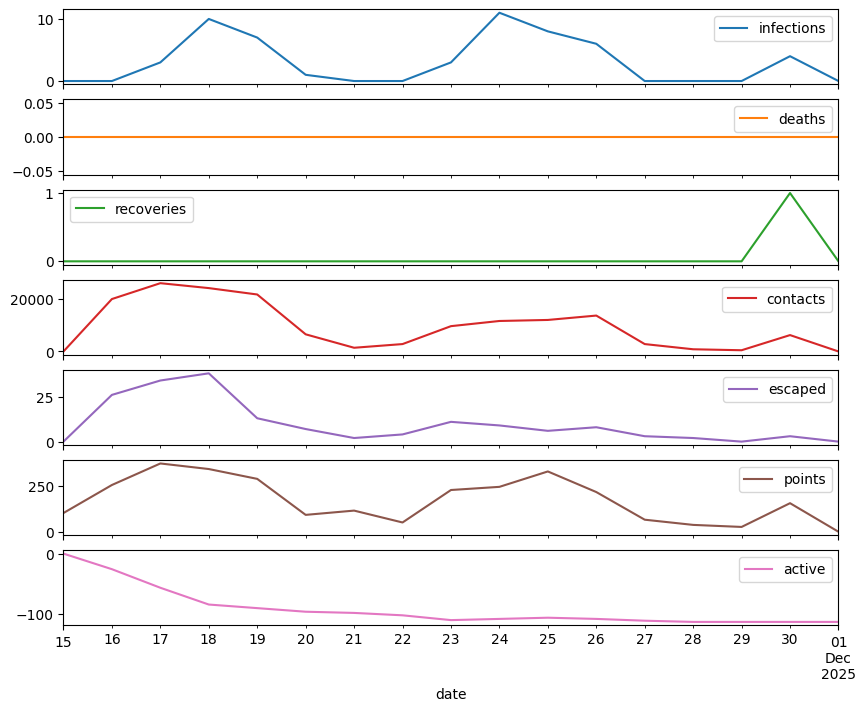

In [66]:
ts = pd.DataFrame({
    "infections": inf_ts,
    "deaths": death_ts,
    "recoveries": rec_ts,
    "contacts": contacts_ts,
    "escaped": esc_ts,
    "points": score_ts,
}).fillna(0)

ts["active"] = ts["infections"].cumsum() - ts["recoveries"].cumsum() - ts["deaths"].cumsum() - ts["escaped"].cumsum()

ts.plot(subplots=True, figsize=(10, 8))

In [16]:
df['type'].value_counts()

type
contact      159500
bluetooth     84241
score          2938
join           1416
modifier       1351
survey          709
quiz            520
outcome         171
vaccine          88
infection        53
illness           6
Name: count, dtype: int64

In [17]:
df[df['type'] == 'infection']

,id,user_id,time,lat,lng,type,inf,falsePostive,out,sim_id,peer_id,contact_length,quiz_id,modifier,score,max_strength,datetime,date
44597,9305605,9770,1763369457,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-17 08:50:57,2025-11-17
55130,9316456,10036,1763375689,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-17 10:34:49,2025-11-17
65066,9326494,9914,1763389453,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-17 14:24:13,2025-11-17
69806,9331277,9838,1763443186,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-18 05:19:46,2025-11-18
88052,9350003,10136,1763459218,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-18 09:46:58,2025-11-18
90318,9352427,9857,1763461410,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-18 10:23:30,2025-11-18
99292,9361319,9762,1763472365,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-18 13:26:05,2025-11-18
101231,9363179,9885,1763482212,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-18 16:10:12,2025-11-18
101539,9363462,9865,1763487054,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-18 17:30:54,2025-11-18
101685,9363601,9754,1763489052,NaN,NaN,infection,CASE0[0],NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-18 18:04:12,2025-11-18


In [18]:
inf_ts 

date
2025-11-17     3
2025-11-18    10
2025-11-19     7
2025-11-20     1
2025-11-23     3
2025-11-24    11
2025-11-25     8
2025-11-26     6
2025-11-30     4
dtype: int64

In [19]:
df

,id,user_id,time,lat,lng,type,inf,falsePostive,out,sim_id,peer_id,contact_length,quiz_id,modifier,score,max_strength,datetime,date
0,9261015,9761,1763223108,NaN,NaN,score,initPoints,NaN,0,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-15 16:11:48,2025-11-15
1,9260937,9750,1763214030,NaN,NaN,modifier,NaN,NaN,NaN,202,NaN,0.0,0.0,model:RMX3370|version:13,0.0,0.0,2025-11-15 13:40:30,2025-11-15
2,9260938,9750,1763214030,NaN,NaN,modifier,NaN,NaN,NaN,202,NaN,0.0,0.0,model:RMX3370|version:13,0.0,0.0,2025-11-15 13:40:30,2025-11-15
3,9260933,9750,1763214028,NaN,NaN,join,NaN,NaN,NaN,202,NaN,NaN,NaN,2508,NaN,NaN,2025-11-15 13:40:28,2025-11-15
4,9260939,9750,1763214030,NaN,NaN,modifier,NaN,NaN,NaN,202,NaN,0.0,0.0,model:RMX3370|version:13,0.0,0.0,2025-11-15 13:40:30,2025-11-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250988,9512297,10044,1764512592,NaN,NaN,bluetooth,"1243324503,9926,51,0.5,1243326637,9926,50,0.5,...",NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-30 14:23:12,2025-11-30
250989,9512298,10044,1764512520,NaN,NaN,bluetooth,"1243262254,9926,51,0.5,1243266554,9926,51,0.5,...",NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-30 14:22:00,2025-11-30
250990,9512299,10044,1764512457,NaN,NaN,bluetooth,"1243187705,9926,49,0.5,1243189905,9926,49,0.5,...",NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-30 14:20:57,2025-11-30
250991,9512300,10044,1764512385,NaN,NaN,bluetooth,"1243119306,9926,52,0.5,1243121407,9926,51,0.5,...",NaN,NaN,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-30 14:19:45,2025-11-30


In [20]:
import pandas as pd

df = pd.read_csv("histories.csv")

df["datetime"] = pd.to_datetime(df["time"], unit="s")

In [21]:
start_time = df["datetime"].min()
end_week1 = start_time + pd.Timedelta(days=7)

week1 = df[
    (df["type"] == "contact") &
    (df["datetime"] < end_week1)
].copy()

In [22]:
week2 = week1.copy()
week2["datetime"] = week2["datetime"] + pd.Timedelta(days=7)

In [23]:
week2["time"] = week2["datetime"].astype("int64") // 10**9

In [24]:
df_contacts_only = df[df["type"] == "contact"]

df_no_contacts = df[df["type"] != "contact"]

In [25]:
new_df = pd.concat([
    df_no_contacts,
    week1,
    week2
])

In [55]:
new_df['time'] = new_df['datetime']
new_df
new_df["id"] = range(len(new_df))
new_df = new_df.drop(columns=['datetime'])


In [56]:
new_df

,id,user_id,time,lat,lng,type,inf,falsePostive,out,sim_id,peer_id,contact_length,quiz_id,modifier,score,max_strength
0,0,9761,2025-11-15 16:11:48,NaN,NaN,score,initPoints,NaN,0,202,NaN,0.0,0.0,NaN,0.0,0.0
1,1,9750,2025-11-15 13:40:30,NaN,NaN,modifier,NaN,NaN,NaN,202,NaN,0.0,0.0,model:RMX3370|version:13,0.0,0.0
2,2,9750,2025-11-15 13:40:30,NaN,NaN,modifier,NaN,NaN,NaN,202,NaN,0.0,0.0,model:RMX3370|version:13,0.0,0.0
3,3,9750,2025-11-15 13:40:28,NaN,NaN,join,NaN,NaN,NaN,202,NaN,NaN,NaN,2508,NaN,NaN
4,4,9750,2025-11-15 13:40:30,NaN,NaN,modifier,NaN,NaN,NaN,202,NaN,0.0,0.0,model:RMX3370|version:13,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218084,294882,9919,2025-11-26 15:20:51,NaN,NaN,contact,NaN,NaN,NaN,202,9762.0,6744.0,0.0,NaN,0.0,-100.0
218085,294883,9919,2025-11-26 15:13:35,NaN,NaN,contact,NaN,NaN,NaN,202,10064.0,18322.0,0.0,NaN,0.0,-100.0
222850,294884,10265,2025-11-26 14:19:51,NaN,NaN,contact,NaN,NaN,NaN,202,10064.0,158376.0,0.0,NaN,0.0,-100.0
244957,294885,10075,2025-11-26 08:00:30,NaN,NaN,contact,NaN,NaN,NaN,202,9892.0,8197.0,0.0,NaN,0.0,-100.0


In [57]:
new_df.to_csv("histories_double_week1.csv")

In [44]:
df[df['out'] == 'ESCAPED']


,id,user_id,time,lat,lng,type,inf,falsePostive,out,sim_id,peer_id,contact_length,quiz_id,modifier,score,max_strength,datetime,date
3330,9264429,9931,1763276548,NaN,NaN,outcome,NaN,NaN,ESCAPED,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-16 07:02:28,2025-11-16
3696,9264822,9765,1763276988,NaN,NaN,outcome,NaN,NaN,ESCAPED,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-16 07:09:48,2025-11-16
4291,9265428,9833,1763277626,NaN,NaN,outcome,NaN,NaN,ESCAPED,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-16 07:20:26,2025-11-16
4924,9266074,9873,1763271064,NaN,NaN,outcome,NaN,NaN,ESCAPED,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-16 05:31:04,2025-11-16
6206,9267352,9868,1763279581,NaN,NaN,outcome,NaN,NaN,ESCAPED,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-16 07:53:01,2025-11-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239996,9502191,9970,1764338165,NaN,NaN,outcome,NaN,NaN,ESCAPED,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-28 13:56:05,2025-11-28
243728,9506085,10116,1764487569,NaN,NaN,outcome,NaN,NaN,ESCAPED,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-30 07:26:09,2025-11-30
245789,9508252,10239,1764494822,NaN,NaN,outcome,NaN,NaN,ESCAPED,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-30 09:27:02,2025-11-30
248465,9511028,10293,1764506915,NaN,NaN,outcome,NaN,NaN,ESCAPED,202,NaN,0.0,0.0,NaN,0.0,0.0,2025-11-30 12:48:35,2025-11-30


In [41]:
df[df['out'] == 'recovered']

,id,user_id,time,lat,lng,type,inf,falsePostive,out,sim_id,peer_id,contact_length,quiz_id,modifier,score,max_strength,datetime,date


In [43]:
df['out'].value_counts()

out
17           784
0            719
10           712
5            198
ESCAPED      166
15            79
8             45
4             45
9             43
3             40
7             38
14            31
12            28
11            25
13            23
-10           22
6             21
-17           17
2             15
-5             7
-20            6
1              6
-34            5
QUIT           4
-30            4
-51            3
-22            2
-68            2
-40            1
-81            1
-6             1
-39            1
-26            1
-52            1
-8             1
-86            1
-71            1
-49            1
-59            1
-21            1
-66            1
-122           1
-4             1
-33            1
-70            1
-95            1
RECOVERED      1
Name: count, dtype: int64

In [67]:
df = df.sort_values("time")

df["datetime"] = pd.to_datetime(df["time"], unit="s")
df["date"] = df["datetime"].dt.floor("D")

In [68]:
df["is_infection"] = df["type"] == "infection"
df["is_recovery"]  = (df["type"] == "outcome") & (df["out"] == "recovered")
df["is_death"]     = (df["type"] == "outcome") & (df["out"] == "dead")
df["is_escape"]    = (df["type"] == "outcome") & (df["out"] == "escaped")

In [69]:
df["delta"] = 0

df.loc[df["is_infection"], "delta"] = 1
df.loc[df["is_recovery"],  "delta"] = -1
df.loc[df["is_death"],     "delta"] = -1

In [70]:
df["infected_state"] = df.groupby("user_id")["delta"].cumsum()

In [71]:
active = (
    df[df["infected_state"] > 0]
    .groupby("date")["user_id"]
    .nunique()
)

In [72]:
ts["active_true"] = active
ts["active_true"] = ts["active_true"].fillna(method="ffill").fillna(0)

TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'

In [ ]:
ts = pd.DataFrame({
    "infections": inf_ts,
    "deaths": death_ts,
    "recoveries": rec_ts,
    "contacts": contacts_ts,
    "escaped": esc_ts,
    "points": score_ts,
}).fillna(0)

ts["active_true"] = ts["infections"].cumsum() - ts["recoveries"].cumsum() - ts["deaths"].cumsum() - ts["escaped"].cumsum()

ts.plot(subplots=True, figsize=(10, 8))

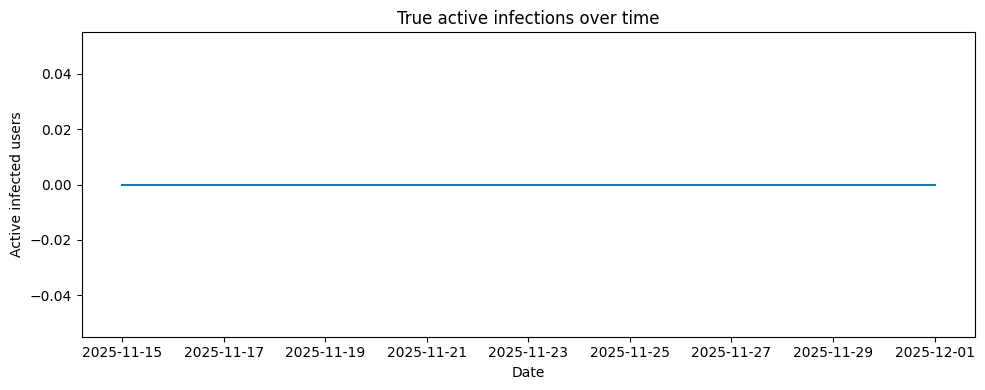